In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import re
from AgentTorch.substep import SubstepTransition
from AgentTorch.helpers import get_by_path

In [56]:
class ProliferateIMCell(SubstepTransition):
    """
        Transition to proliferate the Immune cells
        Update the parameters of the immune cells in state and update the state

        Args:
            config (dict): The input state
            input_variables (dict): The input variables
            output_variables (dict): The output variables
            arguments (dict): The arguments dictionary
        
        Returns:
            state (dict): The updated state

        Parameters:
            proliferate_cell_index (int): The index of the cell to proliferate
            IMpprol (float): The probability of proliferation
            IMprolmax (int): The maximum number of proliferations
            CD8_proliferation_status (int): The proliferation status of the CD8 cells
            CD8_nonproliferation_status (int): The non-proliferation status of the CD8 cells
            CD8_engagement_status (int): The engagement status of the CD8 cells

        Steps:
            1. Feed the input state to the transition function
            2. Get the parameters of the cells in state from the input variables
            3. We update the parameters based on the proliferate_cell_index: (given by the action substep)
                a. If the proliferate_cell_index is the index of the parent immune cells, 
                    we update the parameters of the immune cells by decreasing the capacity parameter
                b. If the proliferate_cell_index is the index of the new daughter immune cells, 
                    we update the parameters of the immune cells by keeping the capacity parameter same
                Rest of the params are same in both the cases
            4. Update the cell grid by altering positions of the cells (proliferation) 

    """
    def __init__(self, config, input_variables, output_variables, arguments):
        super().__init__(config, input_variables, output_variables, arguments)
    
    def forward(self, state):
        input_variables = self.input_variables
        
        # Define the parameters for the cells in state
        proliferate_cell_index = get_by_path(state, re.split("/", input_variables["proliferate_cell_index"])).long()
        IMpprol = get_by_path(state, re.split("/", input_variables["IMpprol"]))
        IMprolmax = get_by_path(state, re.split("/", input_variables["IMprolmax"]))
        CD8_proliferation_status = get_by_path(state, re.split("/", input_variables["CD8_proliferation_status"]))
        CD8_nonproliferation_status = get_by_path(state, re.split("/", input_variables["CD8_non_proliferation_status"]))
        CD8_engagement_status = get_by_path(state, re.split("/", input_variables["CD8_engagement_status"]))
        immune_cells_id = self.config['agents']['immune_cells']['id'].long()
        cell_grid = state['cell_grid']

        def update_parent(agent_id, params):  
            CD8_engagement_status, CD8_nonproliferation_status, CD8_proliferation_status, IMpprol, IMprolmax = torch.unbind(params, dim=-1)
            CD8_proliferation_status[immune_cells_id] = torch.ones_like(CD8_proliferation_status[immune_cells_id])
            CD8_nonproliferation_status[immune_cells_id] = torch.zeros_like(CD8_nonproliferation_status[immune_cells_id])
            CD8_engagement_status[immune_cells_id] = torch.zeros_like(CD8_engagement_status[immune_cells_id])
            IMpprol[immune_cells_id] = IMpprol[immune_cells_id]
            IMprolmax[immune_cells_id] = IMprolmax[immune_cells_id] - 1 
            params = torch.stack([CD8_proliferation_status, CD8_nonproliferation_status, CD8_engagement_status, IMpprol, IMprolmax], dim=-1)  
            return params
        
        def update_daughter(agent_id, params):
            CD8_engagement_status, CD8_nonproliferation_status, CD8_proliferation_status, IMpprol, IMprolmax = torch.unbind(params, dim=-1)
            CD8_proliferation_status[proliferate_cell_index] = torch.ones_like(CD8_proliferation_status[proliferate_cell_index])
            CD8_nonproliferation_status[proliferate_cell_index] = torch.zeros_like(CD8_nonproliferation_status[proliferate_cell_index])
            CD8_engagement_status[proliferate_cell_index] = torch.zeros_like(CD8_engagement_status[proliferate_cell_index])
            IMpprol[proliferate_cell_index] = IMpprol[proliferate_cell_index]
            IMprolmax[proliferate_cell_index] = IMprolmax[proliferate_cell_index]
            params = torch.stack([CD8_proliferation_status, CD8_nonproliferation_status, CD8_engagement_status, IMpprol, IMprolmax], dim=-1)
            return params

        def update_cell_property(agent_id, cell_grid):
            ravel_cell_grid = cell_grid.ravel()
            ravel_cell_grid[proliferate_cell_index] = torch.ones_like(ravel_cell_grid[proliferate_cell_index]) 
            new_cell_grid = ravel_cell_grid.reshape(cell_grid.shape)
            return new_cell_grid
        
        # Update cell grid
        n_agents = state['cell_grid'].ravel().shape[0]
        params = torch.stack([CD8_proliferation_status, CD8_nonproliferation_status, CD8_engagement_status, IMpprol, IMprolmax], dim=-1)
        parent_params = torch.vmap(update_parent, in_dims=(0, None))(proliferate_cell_index, params)
        daughter_params = torch.vmap(update_daughter, in_dims=(0, None))(proliferate_cell_index, params)
        updated_cell_grid = torch.vmap(update_cell_property, in_dims=(0,None))(torch.arange(n_agents), cell_grid)

        # Update state
        CD8_proliferation_status_d, CD8_nonproliferation_status_d, CD8_engagement_status_d, IMpprol_d, IMprolmax_d = torch.unbind(daughter_params, dim=-1)
        CD8_proliferation_status_p, CD8_nonproliferation_status_p, CD8_engagement_status_p, IMpprol_p, IMprolmax_p = torch.unbind(parent_params, dim=-1)
        CD8_proliferation_status[proliferate_cell_index] = CD8_proliferation_status_d
        CD8_proliferation_status[immune_cells_id] = CD8_proliferation_status_p
        CD8_nonproliferation_status[proliferate_cell_index] = CD8_nonproliferation_status_d
        CD8_nonproliferation_status[immune_cells_id] = CD8_nonproliferation_status_p
        CD8_engagement_status[proliferate_cell_index] = CD8_engagement_status_d
        CD8_engagement_status[immune_cells_id] = CD8_engagement_status_p
        IMpprol[proliferate_cell_index] = IMpprol_d
        IMpprol[immune_cells_id] = IMpprol_p
        IMprolmax[proliferate_cell_index] = IMprolmax_d.long()
        IMprolmax[immune_cells_id] = IMprolmax_p.long()
        state['cell_grid'] = updated_cell_grid

        return state

In [57]:
# Create an instance of ProliferateTUCells
config = {
    'agents': {
         'immune_cells': {
                'id': torch.ones_like(torch.randn(10, 10), dtype=torch.int32),
                'proliferate_cell_index': torch.zeros_like(torch.randn(10, 10), dtype=torch.float32, requires_grad=True),
                'IMprolmax': torch.full((10, 10), 10),
                'IMpprol': torch.full((10, 10), 0.049),
                'CD8_proliferation_status': torch.ones_like(torch.rand(10, 10)),
                'CD8_non_proliferation_status': torch.zeros_like(torch.rand(10, 10)),
                'CD8_engagement_status': torch.zeros_like(torch.rand(10, 10)),
         },
    }, 
    'cell_grid': torch.bernoulli(torch.rand(10, 10)),
}
input_variables = {
    'proliferate_cell_index': 'agents/immune_cells/proliferate_cell_index',
    'IMprolmax': 'agents/immune_cells/IMprolmax',
    'IMpprol': 'agents/immune_cells/IMpprol',
    'CD8_proliferation_status': 'agents/immune_cells/CD8_proliferation_status',
    'CD8_non_proliferation_status': 'agents/immune_cells/CD8_non_proliferation_status',
    'CD8_engagement_status': 'agents/immune_cells/CD8_engagement_status',
    'cell_grid': 'agents/immune_cells/cell_grid',
}
output_variables = {} 
arguments = {
    'learnable': {}, 
    'fixed': {}       
}

proliferate_IM_cells = ProliferateIMCell(config, input_variables, output_variables, arguments)

# Forward pass
output_state = proliferate_IM_cells(config)

In [58]:
output_state

{'agents': {'immune_cells': {'id': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
           [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
           [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
           [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
           [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
           [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
           [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
           [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
           [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
           [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]], dtype=torch.int32),
   'proliferate_cell_index': tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
           [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
           [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
           [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
           [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
           [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
           [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
           [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
           [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
           [0.

In [59]:
output_state_sum = sum([torch.sum(tensor) for tensor in output_state['agents']['immune_cells'].values() if isinstance(tensor, torch.Tensor)])

In [51]:
print(output_state_sum)
loss = output_state_sum

tensor(1202.9000, grad_fn=<AddBackward0>)


In [52]:
loss.requires_grad

True

In [53]:
loss.backward()

In [54]:
input_state_sum = sum([torch.sum(tensor) for tensor in config['agents']['immune_cells'].values() if isinstance(tensor, torch.Tensor)])

In [55]:
input_state_sum.requires_grad

True

In [34]:
import torch
import torch.optim as optim

In [35]:
IMcellindex = config['agents']['immune_cells']['proliferate_cell_index']
optimizer = optim.SGD([IMcellindex], lr=0.01)

In [36]:
grad_values = []

for epoch in range(10):
    # Forward pass
    output_state = proliferate_IM_cells(config)
    output_state_sum = sum([torch.sum(tensor) for tensor in output_state['agents']['immune_cells'].values() if isinstance(tensor, torch.Tensor)])
    loss = torch.sum(output_state_sum)
    # Backward pass
    loss.backward()
    # Print or plot the gradient values
    print('Gradient of proliferateIMcell:', IMcellindex.item())
    # Store migrateTUcell.grad values in the list
    grad_values.append(IMcellindex.grad.item())
    # Optimize
    optimizer.step()
    # Print or plot the updated migrateTUcell values
    print('Updated proliferateIMcell:', IMcellindex.item())
    # Print or plot the loss
    print('Loss:', loss.item())
    # Clear gradients for the next iteration
    optimizer.zero_grad()

Gradient of proliferateIMcell: 0.0
Updated proliferateIMcell: -0.019999999552965164
Loss: 14.559782028198242
Gradient of proliferateIMcell: -0.019999999552965164
Updated proliferateIMcell: -0.029999999329447746
Loss: 14.53978157043457
Gradient of proliferateIMcell: -0.029999999329447746
Updated proliferateIMcell: -0.03999999910593033
Loss: 14.529781341552734
Gradient of proliferateIMcell: -0.03999999910593033
Updated proliferateIMcell: -0.04999999701976776
Loss: 14.519781112670898
Gradient of proliferateIMcell: -0.04999999701976776
Updated proliferateIMcell: -0.059999994933605194
Loss: 14.509780883789062
Gradient of proliferateIMcell: -0.059999994933605194
Updated proliferateIMcell: -0.06999999284744263
Loss: 14.499781608581543
Gradient of proliferateIMcell: -0.06999999284744263
Updated proliferateIMcell: -0.07999999076128006
Loss: 14.489781379699707
Gradient of proliferateIMcell: -0.07999999076128006
Updated proliferateIMcell: -0.08999998867511749
Loss: 14.479782104492188
Gradient of 

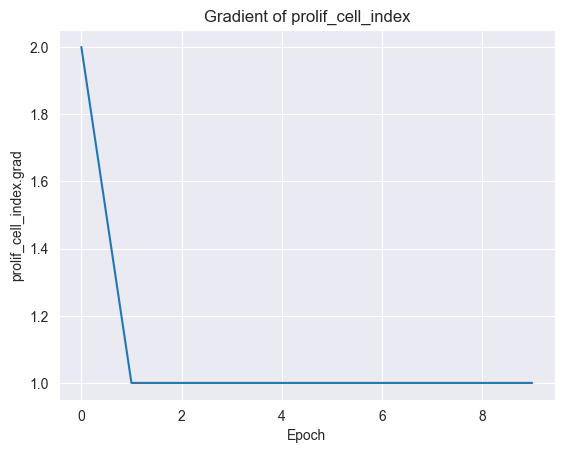

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('darkgrid')
plt.plot(grad_values)
plt.xlabel('Epoch')
plt.ylabel('prolif_cell_index.grad')
plt.title('Gradient of prolif_cell_index')
plt.show()